In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [1]:
from google.colab import files

uploaded = files.upload()


Saving titanic (2).csv to titanic (2) (1).csv


In [2]:
import pandas as pd

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [4]:
print(df.columns.tolist())

print(df["survived"].value_counts())


['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
survived
0    549
1    342
Name: count, dtype: int64


In [6]:
target = "survived"

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())


X shape: (891, 14)
y shape: (891,)

Target distribution:
survived
0    549
1    342
Name: count, dtype: int64


In [7]:
X = pd.get_dummies(X, drop_first=True)

print("Encoded X shape:", X.shape)


Encoded X shape: (891, 23)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)


X_train: (712, 23)
X_val: (179, 23)
y_train: (712,)
y_val: (179,)


In [9]:
print("Missing values in X:")
print(X.isna().sum().sort_values(ascending=False).head(20))

print("\nTotal missing values:", X.isna().sum().sum())


Missing values in X:
age             177
pclass            0
sibsp             0
parch             0
fare              0
adult_male        0
alone             0
sex_male          0
embarked_Q        0
embarked_S        0
class_Second      0
class_Third       0
who_man           0
who_woman         0
deck_B            0
deck_C            0
deck_D            0
deck_E            0
deck_F            0
deck_G            0
dtype: int64

Total missing values: 177


In [11]:
import numpy as np
X = X.replace([np.inf, -np.inf], np.nan)

print("Missing values after replacing infinity:",
      X.isna().sum().sum())


Missing values after replacing infinity: 177


In [12]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)

print("Training missing values:",
      np.isnan(X_train_imputed).sum())

print("Validation missing values:",
      np.isnan(X_val_imputed).sum())


Training missing values: 0
Validation missing values: 0


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)


X_train_scaled: (712, 23)
X_val_scaled: (179, 23)


In [14]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def compare_regularisation(X_train, y_train, X_val, y_val, C_values):

    results = []

    for C in C_values:

        # LASSO - L1
        lasso = LogisticRegression(
            penalty="l1",
            C=C,
            solver="liblinear",
            max_iter=5000,
            random_state=42
        )

        lasso.fit(X_train, y_train)

        lasso_pred = lasso.predict(X_val)

        lasso_acc = accuracy_score(
            y_val,
            lasso_pred
        )

        lasso_nonzero = np.sum(
            np.abs(lasso.coef_) > 1e-6
        )

        # RIDGE - L2
        ridge = LogisticRegression(
            penalty="l2",
            C=C,
            solver="liblinear",
            max_iter=5000,
            random_state=42
        )

        ridge.fit(X_train, y_train)

        ridge_pred = ridge.predict(X_val)

        ridge_acc = accuracy_score(
            y_val,
            ridge_pred
        )

        ridge_nonzero = np.sum(
            np.abs(ridge.coef_) > 1e-6
        )

        # ELASTIC NET - L1 + L2
        elastic = LogisticRegression(
            penalty="elasticnet",
            C=C,
            l1_ratio=0.5,
            solver="saga",
            max_iter=5000,
            random_state=42
        )

        elastic.fit(X_train, y_train)

        elastic_pred = elastic.predict(X_val)

        elastic_acc = accuracy_score(
            y_val,
            elastic_pred
        )

        results.append({
            "C": C,
            "Lasso_val_acc": lasso_acc,
            "Ridge_val_acc": ridge_acc,
            "ElasticNet_val_acc": elastic_acc,
            "Lasso_nonzero": lasso_nonzero,
            "Ridge_nonzero": ridge_nonzero
        })

    return pd.DataFrame(results)


In [19]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

results_df = compare_regularisation(
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    C_values
)

results_df


,C,Lasso_val_acc,Ridge_val_acc,ElasticNet_val_acc,Lasso_nonzero,Ridge_nonzero
0,0.001,0.614525,0.871508,0.614525,0,23
1,0.010,1.000000,0.994413,1.000000,1,23
2,0.100,1.000000,1.000000,1.000000,1,23
3,1.000,1.000000,1.000000,1.000000,1,23
4,10.000,1.000000,1.000000,1.000000,2,23
5,100.000,1.000000,1.000000,1.000000,8,23


In [20]:
best_lasso = results_df.loc[
    results_df["Lasso_val_acc"].idxmax()
]

print("Best Lasso:")
print(best_lasso)

best_ridge = results_df.loc[
    results_df["Ridge_val_acc"].idxmax()
]

print("Best Ridge:")
print(best_ridge)

best_elastic = results_df.loc[
    results_df["ElasticNet_val_acc"].idxmax()
]

print("Best Elastic Net:")
print(best_elastic)


Best Lasso:
C                      0.010000
Lasso_val_acc          1.000000
Ridge_val_acc          0.994413
ElasticNet_val_acc     1.000000
Lasso_nonzero          1.000000
Ridge_nonzero         23.000000
Name: 1, dtype: float64
Best Ridge:
C                      0.1
Lasso_val_acc          1.0
Ridge_val_acc          1.0
ElasticNet_val_acc     1.0
Lasso_nonzero          1.0
Ridge_nonzero         23.0
Name: 2, dtype: float64
Best Elastic Net:
C                      0.010000
Lasso_val_acc          1.000000
Ridge_val_acc          0.994413
ElasticNet_val_acc     1.000000
Lasso_nonzero          1.000000
Ridge_nonzero         23.000000
Name: 1, dtype: float64


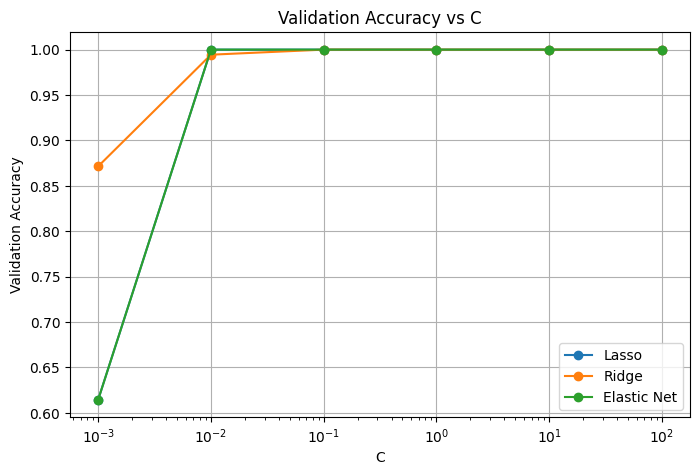

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.semilogx(
    results_df["C"],
    results_df["Lasso_val_acc"],
    marker="o",
    label="Lasso"
)

plt.semilogx(
    results_df["C"],
    results_df["Ridge_val_acc"],
    marker="o",
    label="Ridge"
)

plt.semilogx(
    results_df["C"],
    results_df["ElasticNet_val_acc"],
    marker="o",
    label="Elastic Net"
)

plt.xlabel("C")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs C")
plt.legend()
plt.grid(True)

plt.show()


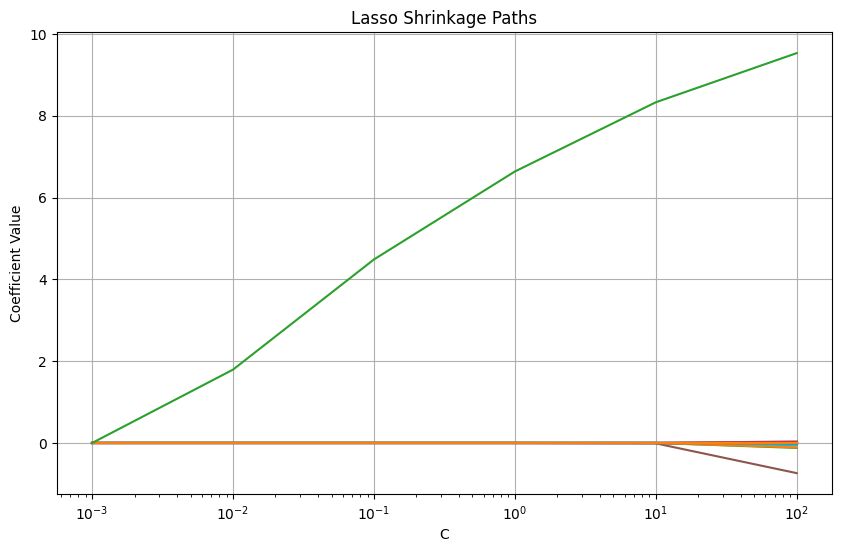

In [23]:
lasso_coefficients = []

for C in C_values:

    model = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=5000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    lasso_coefficients.append(model.coef_[0])

lasso_coefficients = np.array(lasso_coefficients)

plt.figure(figsize=(10, 6))

for i in range(lasso_coefficients.shape[1]):
    plt.semilogx(
        C_values,
        lasso_coefficients[:, i]
    )

plt.xlabel("C")
plt.ylabel("Coefficient Value")
plt.title("Lasso Shrinkage Paths")
plt.grid(True)

plt.show()


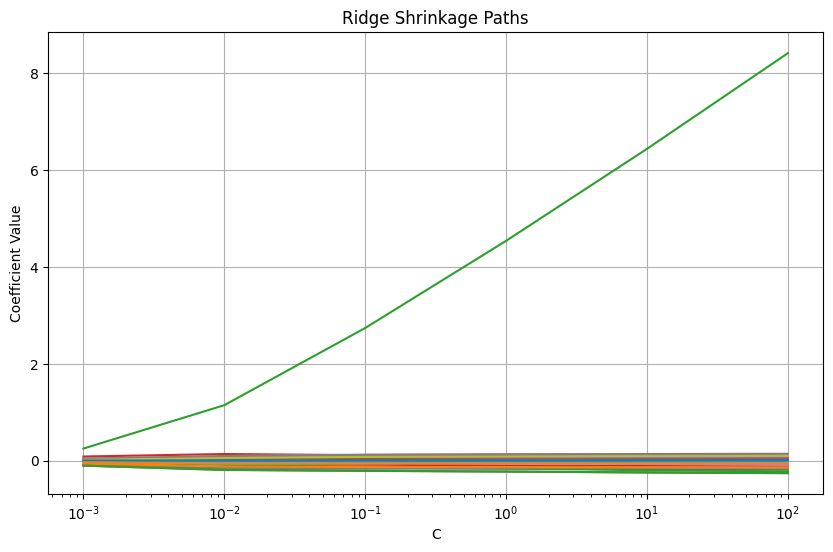

In [24]:
ridge_coefficients = []

for C in C_values:

    model = LogisticRegression(
        penalty="l2",
        C=C,
        solver="liblinear",
        max_iter=5000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    ridge_coefficients.append(model.coef_[0])

ridge_coefficients = np.array(ridge_coefficients)

plt.figure(figsize=(10, 6))

for i in range(ridge_coefficients.shape[1]):
    plt.semilogx(
        C_values,
        ridge_coefficients[:, i]
    )

plt.xlabel("C")
plt.ylabel("Coefficient Value")
plt.title("Ridge Shrinkage Paths")
plt.grid(True)

plt.show()
